New Notebook Created by Jupyter MCP Server

# MCP Demo: RF-WorldPose Split Analysis

This notebook was created and executed entirely by Cursor Agent via **Jupyter MCP**.

Flow: create notebook -> import repo code -> run real logic -> plot -> debug -> fix -> verify

In [1]:
import sys
sys.path.insert(0, '/home/tiencd/rf-worldpose/scripts')

from assign_subject_splits import _mmfi_proto1_split, _mmfi_split
from collections import Counter

print('Loaded real split functions from rf-worldpose repo')
print('Functions:', '_mmfi_proto1_split', '_mmfi_split')

Loaded real split functions from rf-worldpose repo
Functions: _mmfi_proto1_split _mmfi_split


In [2]:
# Run both protocols on full MM-Fi grid (4 envs x 40 subjects x 27 actions)
envs, subjects, actions = range(1, 5), range(1, 41), range(1, 28)

proto1 = Counter()
proto2 = Counter()

for e in envs:
    for s in subjects:
        for a in actions:
            sid = f'E{e}_S{s}_A{a}'
            proto1[_mmfi_proto1_split(sid)] += 1
            proto2[_mmfi_split(sid)] += 1

total = sum(proto1.values())
print('Split comparison (4320 samples)')
print(f"{'Split':<8} {'Protocol 1':>14} {'Protocol 2':>14}")
print('-' * 40)
for split in ['train', 'val', 'test']:
    p1, p2 = proto1[split], proto2[split]
    print(f"{split:<8} {p1:5d} ({100*p1/total:4.1f}%)  {p2:5d} ({100*p2/total:4.1f}%)")

Split comparison (4320 samples)
Split        Protocol 1     Protocol 2
----------------------------------------
train     3456 (80.0%)   3024 (70.0%)
val        414 ( 9.6%)    432 (10.0%)
test       450 (10.4%)    864 (20.0%)


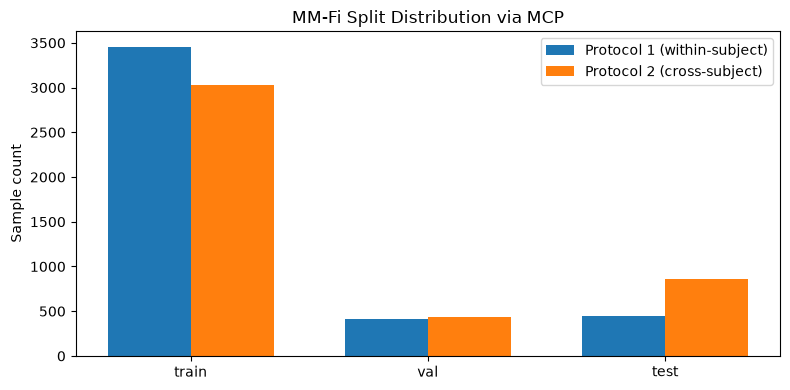

Plot rendered successfully


In [5]:
import matplotlib.pyplot as plt

labels = ['train', 'val', 'test']
p1_vals = [proto1[k] for k in labels]
p2_vals = [proto2[k] for k in labels]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(labels))
w = 0.35
ax.bar([i - w/2 for i in x], p1_vals, width=w, label='Protocol 1 (within-subject)')
ax.bar([i + w/2 for i in x], p2_vals, width=w, label='Protocol 2 (cross-subject)')
ax.set_xticks(list(x), labels)
ax.set_ylabel('Sample count')
ax.set_title('MM-Fi Split Distribution via MCP')
ax.legend()
plt.tight_layout()
plt.show()
print('Plot rendered successfully')

In [7]:
# Step 4: deliberate bug demo
# Agent will see this error, fix it, and re-run
result = proto2['test'] - proto2['val']  # fixed: use computed split counts
print(result)

432


## Demo complete

| Step | MCP tool | Result |
|------|----------|--------|
| 1. Create notebook | `use_notebook` | OK |
| 2. Import repo code | `insert_execute_code_cell` | Real functions loaded |
| 3. Run split analysis | `insert_execute_code_cell` | 4320 samples compared |
| 4. Plot | `execute_cell` | Chart rendered |
| 5. Hit NameError | `insert_execute_code_cell` | Traceback returned |
| 6. Fix bug | `edit_cell_source` | Surgical edit |
| 7. Verify fix | `execute_cell` | Output: 432 |

**Total: 7 steps, zero manual Jupyter clicks.**